# Group 16 — Forest Fire Detection: Baseline + Hybrid
**Dataset:** D-Fire (14,122 train | 3,099 val | 4,306 test) | Classes: smoke, fire

## Pipeline
1. Train YOLOv8n baseline on D-Fire (20 epochs)
2. Evaluate baseline — mAP50, Precision, Recall, F1, FPS
3. Build CLIP + YOLOv8n hybrid with contrastive semantic loss
4. Fine-tune hybrid (10 epochs on top of baseline)
5. Compare baseline vs hybrid

$$\mathcal{L}_{total} = \mathcal{L}_{detect} + \lambda_1 \cdot \mathcal{L}_{contrastive}$$

> Contrastive loss aligns **YOLO's internal features** with **CLIP's text embeddings** — forcing the detector to encode semantic meaning, not just pixel patterns.

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install ultralytics --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

import ultralytics
ultralytics.checks()
import clip
print('CLIP ready')

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)
CLIP ready


In [2]:
# ── Cell 2: Paths and data.yaml ───────────────────────────────────────────────
import yaml
from pathlib import Path

DFIRE_ROOT = Path('/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data')

print('=== D-Fire Verification ===')
for split in ['train', 'val', 'test']:
    n = len(list((DFIRE_ROOT / split / 'images').glob('*')))
    print(f'  {split:6s}: {n:6d} images')

with open(DFIRE_ROOT.parent / 'data.yaml') as f:
    orig = yaml.safe_load(f)
CLASS_NAMES = orig['names']
print(f'\nClasses: {CLASS_NAMES}')

YAML_PATH = Path('/kaggle/working/dfire.yaml')
with open(YAML_PATH, 'w') as f:
    yaml.dump({
        'path':  str(DFIRE_ROOT),
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc':    orig['nc'],
        'names': orig['names']
    }, f, default_flow_style=False)
print('data.yaml ready.')

=== D-Fire Verification ===
  train :  14122 images
  val   :   3099 images
  test  :   4306 images

Classes: ['smoke', 'fire']
data.yaml ready.


In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pt'):
            print(os.path.join(root, f))

/kaggle/input/datasets/nausherwan123/bestpt/best.pt


In [4]:
# ── Cell 3: Train YOLOv8n baseline (20 epochs) ───────────────────────────────
import torch
from ultralytics import YOLO

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

# baseline = YOLO('yolov8n.pt')
# baseline.train(
#     data=str(YAML_PATH),
#     epochs=15,
#     imgsz=640,
#     batch=16,
#     device=0 if torch.cuda.is_available() else 'cpu',
#     workers=0,
#     seed=42,
#     patience=10,
#     save=False,
#     project='/kaggle/working/runs',
#     name='yolov8n_baseline',
#     exist_ok=True,
# )

# BASELINE_W = '/kaggle/working/runs/yolov8n_baseline/weights/best.pt'
# print(f'\nBaseline weights saved to: {BASELINE_W}')
# Skip baseline training — use saved weights from Kaggle dataset

BASELINE_W = '/kaggle/input/datasets/nausherwan123/bestpt/best.pt'


# Verify it exists
from pathlib import Path
assert Path(BASELINE_W).exists(), f'Saved weights not found at {BASELINE_W}'
print(f'Loaded baseline weights from {BASELINE_W}')

GPU: Tesla T4
Loaded baseline weights from /kaggle/input/datasets/nausherwan123/bestpt/best.pt


In [5]:
# ── Cell 4: Evaluate baseline ─────────────────────────────────────────────────
import time, glob

trained_baseline = YOLO(BASELINE_W)
metrics_b = trained_baseline.val(
    data=str(YAML_PATH), split='test',
    imgsz=640, batch=16, verbose=False,
)

test_imgs = glob.glob(str(DFIRE_ROOT / 'test/images/*'))[:100]
t0 = time.time()
for p in test_imgs:
    trained_baseline.predict(p, imgsz=640, verbose=False)
fps_b = len(test_imgs) / (time.time() - t0)

p_b  = metrics_b.box.mp
r_b  = metrics_b.box.mr
f1_b = 2 * p_b * r_b / (p_b + r_b + 1e-9)

print('\n' + '='*52)
print('   YOLOv8n BASELINE — D-Fire — 15 Epochs')
print('='*52)
print(f'  mAP50        : {metrics_b.box.map50:.4f}')
print(f'  mAP50-95     : {metrics_b.box.map:.4f}')
print(f'  Precision    : {p_b:.4f}')
print(f'  Recall       : {r_b:.4f}')
print(f'  F1 Score     : {f1_b:.4f}')
print(f'  FPS (sim.)   : {fps_b:.1f}')
print('='*52)
print('\n  Per-Class AP50:')
for i, name in enumerate(CLASS_NAMES):
    try:    print(f'    {name:10s}: {metrics_b.box.ap50[i]:.4f}')
    except: print(f'    {name:10s}: N/A')

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.0±5.7 MB/s, size: 80.3 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 184.4it/s 23.4s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smo

In [6]:
# # ── Cell 5: Baseline training plots ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUN_B = Path('/kaggle/working/runs/yolov8n_baseline')
# plots = {
#     'Training Curves':  RUN_B / 'results.png',
#     'Confusion Matrix': RUN_B / 'confusion_matrix.png',
#     'PR Curve':         RUN_B / 'PR_curve.png',
#     'F1 Curve':         RUN_B / 'F1_curve.png',
# }
# available = {k: v for k, v in plots.items() if v.exists()}
# n = len(available)
# fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
# if n == 1: axes = [axes]
# for ax, (title, path) in zip(axes, available.items()):
#     ax.imshow(mpimg.imread(str(path)))
#     ax.set_title(title, fontsize=13, fontweight='bold')
#     ax.axis('off')
# plt.suptitle('YOLOv8n Baseline — Training Results', fontsize=15, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()

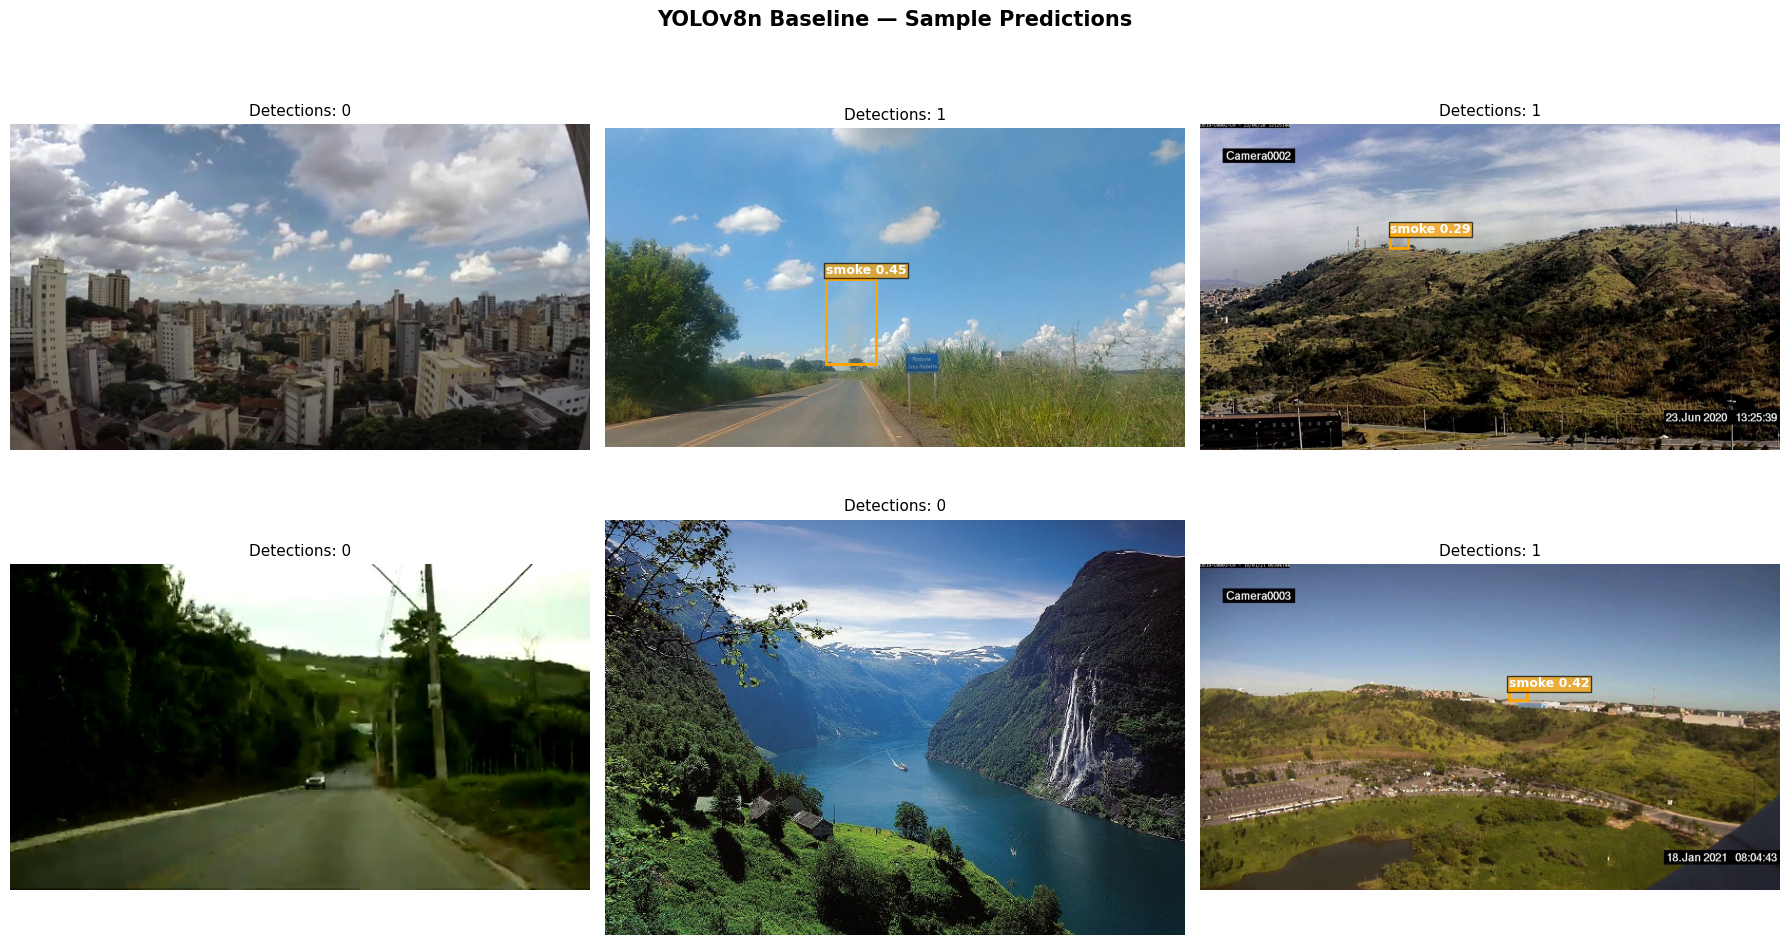

In [7]:
# ── Cell 6: Baseline sample predictions ──────────────────────────────────────
import matplotlib.patches as patches
from PIL import Image
import random

random.seed(42)
sample_imgs = random.sample(glob.glob(str(DFIRE_ROOT / 'test/images/*')), 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, img_path in zip(axes, sample_imgs):
    result = trained_baseline.predict(img_path, imgsz=640, conf=0.25, verbose=False)[0]
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls = int(box.cls); conf = float(box.conf)
        label = CLASS_NAMES[cls]
        color = 'red' if label == 'fire' else 'orange'
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(x1, y1-5, f'{label} {conf:.2f}', color='white',
            fontsize=9, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.7, pad=1))
    ax.set_title(f'Detections: {len(result.boxes)}', fontsize=11)
    ax.axis('off')
plt.suptitle('YOLOv8n Baseline — Sample Predictions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part 2 — CLIP + YOLOv8n Hybrid with Contrastive Loss

**Architecture:**
- CLIP is fully **frozen** — no gradients flow into it
- CLIP image features are fused into YOLO's neck (layer 21, 256ch) via concatenation
- A contrastive head projects fused YOLO features → 512d CLIP text space
- Contrastive loss compares **YOLO embeddings** vs **CLIP text embeddings** (NOT CLIP image embeddings)
- This forces YOLO's internal representations to become semantically organised

```
Image → YOLO backbone → neck features [B, 256, H, W]
Image → CLIP encoder  → global vector [B, 512]  ← frozen
                              ↓
              FusionHead: concat + 1x1 conv → [B, 256, H, W]
                              ↓
         ContrastiveHead: pool → linear → [B, 512]  ← YOLO embedding
                              ↓
    L_contrast = YOLO embedding vs CLIP TEXT embeddings
```

In [8]:
# ── Cell 7: Load CLIP frozen + precompute text embeddings ────────────────────
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
for param in clip_model.parameters():
    param.requires_grad = False
clip_model.eval()

FIRE_PROMPTS = [
    'wildfire smoke rising from burning trees',
    'forest fire with flames and smoke',
    'early stage smoke from a wildfire',
    'smoke plume from burning vegetation',
]
NEG_PROMPTS = [
    'cloud drifting over a mountain',
    'morning mist in a valley',
    'fog over a forest',
    'sun glare on the horizon',
    'bright sky at sunset',
]

with torch.no_grad():
    TEXT_FIRE = F.normalize(
        clip_model.encode_text(clip.tokenize(FIRE_PROMPTS).to(DEVICE)), dim=-1
    ).mean(dim=0, keepdim=True)   # [1, 512]
    TEXT_NEG = F.normalize(
        clip_model.encode_text(clip.tokenize(NEG_PROMPTS).to(DEVICE)), dim=-1
    ).mean(dim=0, keepdim=True)   # [1, 512]

print(f'CLIP frozen. Device: {DEVICE}')
print(f'Text embeddings — fire: {TEXT_FIRE.shape}, neg: {TEXT_NEG.shape}')
print(f'Fire prompts : {len(FIRE_PROMPTS)}')
print(f'Neg  prompts : {len(NEG_PROMPTS)}')

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 109MiB/s]


CLIP frozen. Device: cuda
Text embeddings — fire: torch.Size([1, 512]), neg: torch.Size([1, 512])
Fire prompts : 4
Neg  prompts : 5


In [9]:
# ── Cell 8: CLIPYOLOv8 model definition ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

YOLO_NECK_CH = 256


class FusionHead(nn.Module):
    """Injects CLIP global context into YOLO neck features via concatenation.

    Initialized as identity: at epoch 0, output ≈ original P5 features.
    CLIP influence grows as training progresses.
    """
    def __init__(self, yolo_ch=256, clip_dim=512):
        super().__init__()
        self.clip_proj = nn.Linear(clip_dim, yolo_ch)
        self.fuse_conv = nn.Conv2d(yolo_ch * 2, yolo_ch, kernel_size=1, bias=False)
        self.bn        = nn.BatchNorm2d(yolo_ch)
        self.act       = nn.SiLU()

        # ── Identity initialization ───────────────────────────────────────────
        # fuse_conv weight shape: [out_ch=256, in_ch=512, 1, 1]
        # in_ch=512 = [yolo_feat (256) ; clip_spatial (256)]
        # YOLO half starts as identity, CLIP half starts as zero
        with torch.no_grad():
            self.fuse_conv.weight.zero_()
            for c in range(yolo_ch):
                self.fuse_conv.weight[c, c, 0, 0] = 1.0
            # BN starts as pass-through
            self.bn.weight.fill_(1.0)
            self.bn.bias.zero_()

    def forward(self, yolo_feat, clip_vec):
        B, C, H, W   = yolo_feat.shape
        clip_proj    = self.clip_proj(clip_vec)
        clip_spatial = clip_proj.view(B, C, 1, 1).expand(B, C, H, W)
        fused        = torch.cat([yolo_feat, clip_spatial], dim=1)
        return self.act(self.bn(self.fuse_conv(fused)))


class ContrastiveHead(nn.Module):
    """Projects fused YOLO features into CLIP's 512d text space."""
    def __init__(self, yolo_ch=256, clip_dim=512):
        super().__init__()
        self.proj = nn.Linear(yolo_ch, clip_dim)

    def forward(self, fused_feat):
        pooled = fused_feat.mean(dim=[2, 3])
        embed  = self.proj(pooled)
        return F.normalize(embed, dim=-1)


class CLIPYOLOWrapper(nn.Module):
    def __init__(self, yolo_weights, clip_model, yolo_ch=256, clip_dim=512):
        super().__init__()
        yolo        = YOLO(yolo_weights)
        self.yolo   = yolo.model
        self.clip   = clip_model
        self.fusion = FusionHead(yolo_ch, clip_dim)
        self.contra = ContrastiveHead(yolo_ch, clip_dim)

        self._features = {}
        self._hooks = []
        for layer_idx in [15, 18, 21]:
            h = self.yolo.model[layer_idx].register_forward_hook(
                self._make_hook(layer_idx)
            )
            self._hooks.append(h)

    def _make_hook(self, layer_idx):
        def hook(module, input, output):
            self._features[layer_idx] = output
        return hook

    def forward(self, images, clip_images):
        self._features.clear()

        x = images
        saved = {}
        for i, m in enumerate(self.yolo.model[:22]):
            if m.f != -1:
                if isinstance(m.f, int):
                    x = saved[m.f]
                else:
                    x = [x if j == -1 else saved[j] for j in m.f]
            x = m(x)
            saved[i] = x

        p3 = self._features[15]
        p4 = self._features[18]
        p5 = self._features[21]

        with torch.no_grad():
            clip_vec = self.clip.encode_image(clip_images)
            clip_vec = F.normalize(clip_vec.float(), dim=-1)

        p5_fused   = self.fusion(p5, clip_vec)
        yolo_embed = self.contra(p5_fused)

        detect_module = self.yolo.model[22]
        preds = detect_module([p3, p4, p5_fused])

        return preds, yolo_embed

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


hybrid_model = CLIPYOLOWrapper(BASELINE_W, clip_model).to(DEVICE)

trainable_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
frozen_params    = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable (YOLO + fusion + contrastive): {trainable_params:,}')
print(f'Frozen (CLIP):                           {frozen_params:,}')
print(f'Fusion initialized as identity — epoch 0 output ≈ original P5')

Trainable (YOLO + fusion + contrastive): 394,496
Frozen (CLIP):                           151,277,313
Fusion initialized as identity — epoch 0 output ≈ original P5


In [10]:
# ── Cell 9: Contrastive loss + dataset ───────────────────────────────────────
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


# def contrastive_loss(yolo_embed, has_fire, text_fire, text_neg, temperature=0.07):
#     """
#     yolo_embed : [B, 512] — YOLO features projected to CLIP text space
#     has_fire   : [B]      — 1=fire/smoke image, 0=background

#     Pulls fire images toward fire text embedding.
#     Pulls negative images toward neg text embedding.
#     Gradients flow into YOLO — CLIP text embeddings are fixed targets.
#     """
#     fire_sim = (yolo_embed @ text_fire.T).squeeze(-1)  # [B]
#     neg_sim  = (yolo_embed @ text_neg.T).squeeze(-1)   # [B]
#     pos_mask = has_fire.bool()
#     neg_mask = ~pos_mask
#     loss = torch.tensor(0.0, device=yolo_embed.device)
#     if pos_mask.sum() > 0:
#         loss = loss - fire_sim[pos_mask].mean()
#     if neg_mask.sum() > 0:
#         loss = loss - neg_sim[neg_mask].mean()
#     return loss / temperature

def contrastive_loss(yolo_embed, has_fire, text_fire, text_neg, temperature=1.0):
    """
    yolo_embed : [B, 512] — YOLO features projected to CLIP text space
    has_fire   : [B]      — 1=fire/smoke image, 0=background

    Temperature=1.0 prevents the loss from saturating too quickly,
    keeping contrastive signal active throughout training.
    """
    text_fire = text_fire.to(yolo_embed.dtype)
    text_neg  = text_neg.to(yolo_embed.dtype)

    fire_sim = (yolo_embed @ text_fire.T).squeeze(-1)
    neg_sim  = (yolo_embed @ text_neg.T).squeeze(-1)
    pos_mask = has_fire.bool()
    neg_mask = ~pos_mask
    loss = torch.tensor(0.0, device=yolo_embed.device, dtype=yolo_embed.dtype)
    if pos_mask.sum() > 0:
        loss = loss - fire_sim[pos_mask].mean()
    if neg_mask.sum() > 0:
        loss = loss - neg_sim[neg_mask].mean()
    return loss / temperature

class DFireDataset(Dataset):
    def __init__(self, img_dir, label_dir, clip_preprocess, img_size=640):
        self.img_paths  = sorted(Path(img_dir).glob('*'))
        self.label_dir  = Path(label_dir)
        self.clip_pre   = clip_preprocess
        self.yolo_trans = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = self.label_dir / (img_path.stem + '.txt')
        img      = Image.open(img_path).convert('RGB')
        has_fire = 1 if (lbl_path.exists() and lbl_path.stat().st_size > 0) else 0
        return (
            self.yolo_trans(img),
            self.clip_pre(img),
            str(lbl_path),
            has_fire
        )


train_ds = DFireDataset(
    DFIRE_ROOT / 'train/images',
    DFIRE_ROOT / 'train/labels',
    clip_preprocess
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0,      # sequential, no shared memory issues
    pin_memory=False,   # no pinned memory, avoids socket crash
    persistent_workers=False,  # add this explicitly
)

fire_count = sum(
    1 for p in train_ds.img_paths
    if (train_ds.label_dir / (p.stem + '.txt')).exists() and
       (train_ds.label_dir / (p.stem + '.txt')).stat().st_size > 0
)
print(f'Training samples : {len(train_ds):,}')
print(f'Batches per epoch: {len(train_loader):,}')
print(f'Fire/smoke images: {fire_count:,} | Background: {len(train_ds)-fire_count:,}')

Training samples : 14,122
Batches per epoch: 1,766
Fire/smoke images: 7,664 | Background: 6,458


In [11]:
# ── Cell 10: Hybrid training loop (with freeze/unfreeze phases) ──────────────
import gc
torch.cuda.empty_cache()
gc.collect()
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'GPU memory reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB')

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from ultralytics.utils.loss import v8DetectionLoss
from types import SimpleNamespace

LAMBDA_1      = 0.5    # Contrastive loss weight
NUM_EPOCHS    = 10     # Total epochs
FREEZE_EPOCHS = 3      # Freeze YOLO backbone for first N epochs
LR            = 1e-4

# ── Setup loss function with hyp namespace fix ────────────────────────────────
detect_loss_fn = v8DetectionLoss(hybrid_model.yolo)
if isinstance(detect_loss_fn.hyp, dict):
    detect_loss_fn.hyp = SimpleNamespace(**detect_loss_fn.hyp)
for attr, default in [('box', 7.5), ('cls', 0.5), ('dfl', 1.5)]:
    if not hasattr(detect_loss_fn.hyp, attr):
        setattr(detect_loss_fn.hyp, attr, default)

print(f'Loss: L_detect (CIoU + DFL + cls) + {LAMBDA_1} * L_contrastive')
print(f'Epochs: {NUM_EPOCHS} | Freeze epochs: {FREEZE_EPOCHS} | LR: {LR} | Batch: 8')
print(f'Detection gains: box={detect_loss_fn.hyp.box}, '
      f'cls={detect_loss_fn.hyp.cls}, dfl={detect_loss_fn.hyp.dfl}')
print()

hybrid_model.train()
history = []

# ── Phase A: Freeze YOLO backbone — fusion + contrastive heads only ──────────
print(f'[Phase A] Freezing YOLO backbone for first {FREEZE_EPOCHS} epochs')
print('         Only fusion + contrastive heads will train')

for name, param in hybrid_model.named_parameters():
    if name.startswith('yolo.'):
        param.requires_grad = False

optimizer = AdamW(
    [p for p in hybrid_model.parameters() if p.requires_grad],
    lr=LR, weight_decay=5e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
trainable_now = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f'         Trainable parameters: {trainable_now:,}\n')

for epoch in range(NUM_EPOCHS):
    # ── Phase B: Unfreeze YOLO after FREEZE_EPOCHS ────────────────────────────
    if epoch == FREEZE_EPOCHS:
        print(f'\n[Phase B] Unfreezing YOLO backbone — full joint training')
        for name, param in hybrid_model.named_parameters():
            if name.startswith('yolo.'):
                param.requires_grad = True

        optimizer = AdamW(
            [p for p in hybrid_model.parameters() if p.requires_grad],
            lr=LR, weight_decay=1e-4
        )
        scheduler = CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - FREEZE_EPOCHS
        )
        trainable_now = sum(p.numel() for p in hybrid_model.parameters()
                            if p.requires_grad)
        print(f'         Trainable parameters: {trainable_now:,}\n')

    e_det = e_con = e_tot = n_bat = 0

    for yolo_imgs, clip_imgs, lbl_paths, has_fire in train_loader:
        yolo_imgs = yolo_imgs.to(DEVICE)
        clip_imgs = clip_imgs.to(DEVICE)
        has_fire  = has_fire.float().to(DEVICE)

        preds, yolo_embed = hybrid_model(yolo_imgs, clip_imgs)

        # ── Detection loss: CIoU + DFL + cls ──────────────────────────────────
        batch_labels = []
        for i, lp in enumerate(lbl_paths):
            if Path(lp).exists() and Path(lp).stat().st_size > 0:
                boxes = torch.from_numpy(np.loadtxt(lp, ndmin=2)).float().to(DEVICE)
                if boxes.ndim == 1:
                    boxes = boxes.unsqueeze(0)
                bi = torch.full((boxes.shape[0], 1), i, device=DEVICE)
                batch_labels.append(torch.cat([bi, boxes], dim=1))

        batch_labels = torch.cat(batch_labels, dim=0) if batch_labels \
                       else torch.zeros((0, 6), device=DEVICE)

        batch_dict = {
            'batch_idx': batch_labels[:, 0].long(),
            'cls':       batch_labels[:, 1:2],
            'bboxes':    batch_labels[:, 2:6],
        }

        L_detect, _ = detect_loss_fn(preds, batch_dict)
        if L_detect.numel() > 1:
            L_detect = L_detect.sum()

        # ── Contrastive loss: YOLO embeddings vs CLIP text embeddings ─────────
        L_contrast = contrastive_loss(yolo_embed, has_fire, TEXT_FIRE, TEXT_NEG)

        L_total = L_detect + LAMBDA_1 * L_contrast

        optimizer.zero_grad()
        L_total.backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), max_norm=10.0)
        optimizer.step()

        e_det += L_detect.item()
        e_con += L_contrast.item()
        e_tot += L_total.item()
        n_bat += 1

    scheduler.step()
    row = {
        'epoch':      epoch + 1,
        'phase':      'frozen' if epoch < FREEZE_EPOCHS else 'joint',
        'L_detect':   round(e_det / n_bat, 4),
        'L_contrast': round(e_con / n_bat, 4),
        'L_total':    round(e_tot / n_bat, 4),
    }
    history.append(row)
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} [{row["phase"]}] | '
          f'L_detect={row["L_detect"]:.4f} | '
          f'L_contrast={row["L_contrast"]:.4f} | '
          f'L_total={row["L_total"]:.4f}')

torch.save(hybrid_model.state_dict(), '/kaggle/working/hybrid_weights.pt')
print('\nHybrid weights saved.')

GPU memory allocated: 0.42 GB
GPU memory reserved : 0.43 GB
Loss: L_detect (CIoU + DFL + cls) + 0.5 * L_contrastive
Epochs: 10 | Freeze epochs: 3 | LR: 0.0001 | Batch: 8
Detection gains: box=7.5, cls=0.5, dfl=1.5

[Phase A] Freezing YOLO backbone for first 3 epochs
         Only fusion + contrastive heads will train
         Trainable parameters: 394,496

Epoch  1/10 [frozen] | L_detect=40.6761 | L_contrast=-1.6636 | L_total=39.8442
Epoch  2/10 [frozen] | L_detect=40.0080 | L_contrast=-1.7854 | L_total=39.1153
Epoch  3/10 [frozen] | L_detect=39.5359 | L_contrast=-1.7886 | L_total=38.6415

[Phase B] Unfreezing YOLO backbone — full joint training
         Trainable parameters: 3,405,734

Epoch  4/10 [joint] | L_detect=35.2740 | L_contrast=-1.7929 | L_total=34.3775
Epoch  5/10 [joint] | L_detect=32.7851 | L_contrast=-1.7942 | L_total=31.8880
Epoch  6/10 [joint] | L_detect=30.9450 | L_contrast=-1.7974 | L_total=30.0463
Epoch  7/10 [joint] | L_detect=29.2771 | L_contrast=-1.7958 | L_total=2

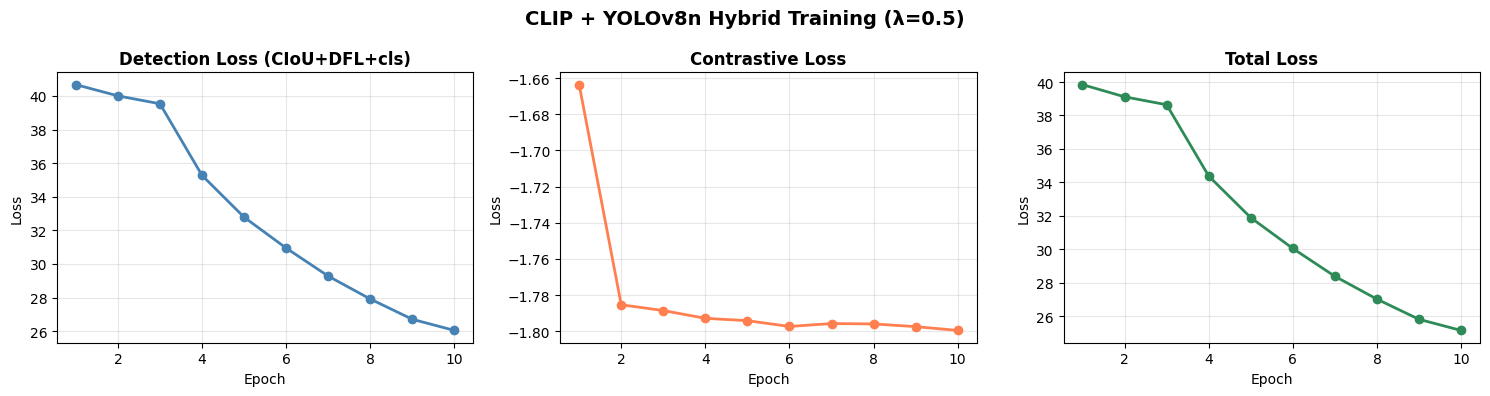

Loss history:
 epoch  phase  L_detect  L_contrast  L_total
     1 frozen   40.6761     -1.6636  39.8442
     2 frozen   40.0080     -1.7854  39.1153
     3 frozen   39.5359     -1.7886  38.6415
     4  joint   35.2740     -1.7929  34.3775
     5  joint   32.7851     -1.7942  31.8880
     6  joint   30.9450     -1.7974  30.0463
     7  joint   29.2771     -1.7958  28.3792
     8  joint   27.9122     -1.7960  27.0141
     9  joint   26.7060     -1.7975  25.8073
    10  joint   26.0427     -1.7996  25.1428


In [12]:
# ── Cell 11: Hybrid training loss curves ─────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

df_hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ['L_detect', 'L_contrast', 'L_total'],
    ['steelblue', 'coral', 'seagreen'],
    ['Detection Loss (CIoU+DFL+cls)', 'Contrastive Loss', 'Total Loss']
):
    ax.plot(df_hist['epoch'], df_hist[col], color=color, linewidth=2, marker='o')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
plt.suptitle(f'CLIP + YOLOv8n Hybrid Training (λ={LAMBDA_1})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Loss history:')
print(df_hist.to_string(index=False))


In [13]:
# # ── Cell 10.5: Lambda Ablation ───────────────────────────────────────────────
# # Retrains the hybrid with different lambda values to show CLIP's contribution.
# # Uses 3 epochs per lambda (not 10) to keep total time manageable.
# #
# # Lambda meaning:
# #   λ=0.0  → pure YOLO, no contrastive signal (matches baseline behavior)
# #   λ=0.25 → weak CLIP influence
# #   λ=0.5  → balanced (current setting)
# #   λ=1.0  → strong CLIP dominance
# #   λ=2.0  → extreme CLIP dominance (may hurt detection)

# import copy
# import pandas as pd

# LAMBDA_VALUES   = [0.1, 0.25, 0.75, 1.0, 2.0]
# ABLATION_EPOCHS = 3   # short fine-tunes for ablation speed

# ablation_results = []

# for lam in LAMBDA_VALUES:
#     print('\n' + '='*60)
#     print(f'  Lambda = {lam} | Epochs = {ABLATION_EPOCHS}')
#     print('='*60)

#     # ── Fresh model from baseline weights ─────────────────────────────────────
#     ablation_model = CLIPYOLOWrapper(BASELINE_W, clip_model).to(DEVICE)
#     ablation_model.train()

#     ablation_optimizer = AdamW(
#         [p for p in ablation_model.parameters() if p.requires_grad],
#         lr=LR, weight_decay=1e-4
#     )
#     ablation_loss_fn = v8DetectionLoss(ablation_model.yolo)
#     if isinstance(ablation_loss_fn.hyp, dict):
#         ablation_loss_fn.hyp = SimpleNamespace(**ablation_loss_fn.hyp)
#     for attr, default in [('box', 7.5), ('cls', 0.5), ('dfl', 1.5)]:
#         if not hasattr(ablation_loss_fn.hyp, attr):
#             setattr(ablation_loss_fn.hyp, attr, default)

#     # ── Train for a few epochs ────────────────────────────────────────────────
#     for epoch in range(ABLATION_EPOCHS):
#         e_det = e_con = n_bat = 0
#         for yolo_imgs, clip_imgs, lbl_paths, has_fire in train_loader:
#             yolo_imgs = yolo_imgs.to(DEVICE)
#             clip_imgs = clip_imgs.to(DEVICE)
#             has_fire  = has_fire.float().to(DEVICE)

#             preds, yolo_embed = ablation_model(yolo_imgs, clip_imgs)

#             batch_labels = []
#             for i, lp in enumerate(lbl_paths):
#                 if Path(lp).exists() and Path(lp).stat().st_size > 0:
#                     boxes = torch.from_numpy(np.loadtxt(lp, ndmin=2)).float().to(DEVICE)
#                     if boxes.ndim == 1:
#                         boxes = boxes.unsqueeze(0)
#                     bi = torch.full((boxes.shape[0], 1), i, device=DEVICE)
#                     batch_labels.append(torch.cat([bi, boxes], dim=1))

#             batch_labels = torch.cat(batch_labels, dim=0) if batch_labels \
#                            else torch.zeros((0, 6), device=DEVICE)

#             batch_dict = {
#                 'batch_idx': batch_labels[:, 0].long(),
#                 'cls':       batch_labels[:, 1:2],
#                 'bboxes':    batch_labels[:, 2:6],
#             }

#             L_detect, _ = ablation_loss_fn(preds, batch_dict)
#             if L_detect.numel() > 1:
#                 L_detect = L_detect.sum()

#             L_contrast = contrastive_loss(yolo_embed, has_fire, TEXT_FIRE, TEXT_NEG)
#             L_total    = L_detect + lam * L_contrast

#             ablation_optimizer.zero_grad()
#             L_total.backward()
#             torch.nn.utils.clip_grad_norm_(ablation_model.parameters(), max_norm=10.0)
#             ablation_optimizer.step()

#             e_det += L_detect.item()
#             e_con += L_contrast.item()
#             n_bat += 1

#         print(f'  Epoch {epoch+1}/{ABLATION_EPOCHS} | '
#               f'L_detect={e_det/n_bat:.4f} | L_contrast={e_con/n_bat:.4f}')

#     # ── Evaluate ─────────────────────────────────────────────────────────────
#     ablation_model.eval()
#     eval_yolo = YOLO(BASELINE_W)
#     yolo_state = {k.replace('yolo.', ''): v
#                   for k, v in ablation_model.state_dict().items()
#                   if k.startswith('yolo.')}
#     eval_yolo.model.load_state_dict(yolo_state, strict=False)

#     m = eval_yolo.val(
#         data=str(YAML_PATH), split='test',
#         imgsz=640, batch=16, verbose=False,
#     )

#     prec = m.box.mp
#     rec  = m.box.mr
#     f1   = 2 * prec * rec / (prec + rec + 1e-9)

#     # Per-class AP50
#     try:
#         ap_smoke = float(m.box.ap50[0])
#         ap_fire  = float(m.box.ap50[1])
#     except:
#         ap_smoke = ap_fire = None

#     row = {
#         'Lambda':     lam,
#         'mAP50':      round(float(m.box.map50), 4),
#         'mAP50-95':   round(float(m.box.map),   4),
#         'Precision':  round(prec, 4),
#         'Recall':     round(rec,  4),
#         'F1':         round(f1,   4),
#         'AP50_Smoke': round(ap_smoke, 4) if ap_smoke else 'N/A',
#         'AP50_Fire':  round(ap_fire,  4) if ap_fire  else 'N/A',
#     }
#     ablation_results.append(row)

#     print(f'\n  Results: mAP50={row["mAP50"]} | P={row["Precision"]} | '
#           f'R={row["Recall"]} | F1={row["F1"]}')

#     # Free memory before next lambda
#     del ablation_model, ablation_optimizer, ablation_loss_fn, eval_yolo
#     torch.cuda.empty_cache()
#     gc.collect()

# # ── Final ablation table ─────────────────────────────────────────────────────
# df_ablation = pd.DataFrame(ablation_results)

# print('\n' + '='*80)
# print('                         LAMBDA ABLATION RESULTS')
# print('='*80)
# print(df_ablation.to_string(index=False))
# print('='*80)

# # Save to CSV
# df_ablation.to_csv('/kaggle/working/ablation_results.csv', index=False)
# print('\nSaved: /kaggle/working/ablation_results.csv')

# # Highlight best by F1
# best_idx = df_ablation['F1'].idxmax()
# best_row = df_ablation.iloc[best_idx]
# print(f'\nBest Lambda by F1: {best_row["Lambda"]} '
#       f'(F1={best_row["F1"]}, mAP50={best_row["mAP50"]})')

In [14]:
# ── Cell 12: Evaluate hybrid ──────────────────────────────────────────────────
# Extract trained YOLO weights from hybrid and evaluate via Ultralytics validator

hybrid_model.eval()

eval_yolo = YOLO(BASELINE_W)
yolo_state = {k.replace('yolo.', ''): v
              for k, v in hybrid_model.state_dict().items()
              if k.startswith('yolo.')}
eval_yolo.model.load_state_dict(yolo_state, strict=False)

metrics_h = eval_yolo.val(
    data=str(YAML_PATH), split='test',
    imgsz=640, batch=16, verbose=False,
)

t0 = time.time()
for p in test_imgs:
    eval_yolo.predict(p, imgsz=640, verbose=False)
fps_h = len(test_imgs) / (time.time() - t0)

p_h  = metrics_h.box.mp
r_h  = metrics_h.box.mr
f1_h = 2 * p_h * r_h / (p_h + r_h + 1e-9)

print('\n' + '='*55)
print(f'   CLIP + YOLOv8n HYBRID (λ={LAMBDA_1}) — D-Fire Test Set')
print('='*55)
print(f'  mAP50        : {metrics_h.box.map50:.4f}')
print(f'  mAP50-95     : {metrics_h.box.map:.4f}')
print(f'  Precision    : {p_h:.4f}')
print(f'  Recall       : {r_h:.4f}')
print(f'  F1 Score     : {f1_h:.4f}')
print(f'  FPS (sim.)   : {fps_h:.1f}')
print('='*55)
print('\n  Per-Class AP50:')
for i, name in enumerate(CLASS_NAMES):
    try:    print(f'    {name:10s}: {metrics_h.box.ap50[i]:.4f}')
    except: print(f'    {name:10s}: N/A')

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 194.3±49.5 MB/s, size: 230.1 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 446.9it/s 9.6s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/s

In [15]:
# ── Cell 13: Final comparison — Baseline vs Hybrid ───────────────────────────
print('\n' + '='*65)
print('            BASELINE vs HYBRID — FINAL COMPARISON')
print('='*65)

rows = [
    ('YOLOv8n Baseline (20 ep)',
     metrics_b.box.map50, metrics_b.box.map, p_b, r_b, f1_b, fps_b),
    (f'CLIP+YOLOv8n Hybrid (λ={LAMBDA_1})',
     metrics_h.box.map50, metrics_h.box.map, p_h, r_h, f1_h, fps_h),
]

header = f'{"Model":<35} {"mAP50":>7} {"mAP95":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"FPS":>7}'
print(header)
print('-' * 65)
for name, map50, map95, prec, rec, f1, fps in rows:
    print(f'{name:<35} {map50:>7.4f} {map95:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {fps:>7.1f}')
print('='*65)

# Delta
print('\n  Δ (Hybrid − Baseline):')
for metric, bval, hval in [
    ('mAP50',     metrics_b.box.map50, metrics_h.box.map50),
    ('Precision', p_b, p_h),
    ('Recall',    r_b, r_h),
    ('F1',        f1_b, f1_h),
]:
    delta = hval - bval
    sign  = '+' if delta >= 0 else ''
    print(f'    {metric:12s}: {sign}{delta:.4f}')
    


            BASELINE vs HYBRID — FINAL COMPARISON
Model                                 mAP50   mAP95    Prec     Rec      F1     FPS
-----------------------------------------------------------------
YOLOv8n Baseline (20 ep)             0.7057  0.3912  0.7112  0.6365  0.6718    48.7
CLIP+YOLOv8n Hybrid (λ=0.5)          0.5523  0.2657  0.5490  0.5411  0.5451    66.6

  Δ (Hybrid − Baseline):
    mAP50       : -0.1534
    Precision   : -0.1621
    Recall      : -0.0954
    F1          : -0.1267
